# WR RNN - Raw Features + All Improvements

Key changes from the original `WR_Career_RNN_Optuna.ipynb` (R2=0.2157):

| Aspect | Original RNN | This RNN |
|---|---|---|
| Sequence features | 184 lag1/roll5 per timestep | ~30 raw game stats |
| Static features | None (everything in sequence) | 20 pregame/career features via separate branch |
| Short careers | Dropped (seq_len filter) | Padded + Masking (no data lost) |
| Architecture | 1-4 layers, 64-512 units | Max 2 layers, max 192 units |
| Normalization | Optional (Optuna chose 'none') | Forced LayerNorm |
| Input regularization | None | GaussianNoise on static branch |
| Sample weights | Original [1.0, 4.12] | Searched strength [0.5, 1.0] |
| Optuna space | ~20 params, 100 trials | ~15 params (constrained), 100 trials |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import os, json, gc, time, random

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks, optimizers, losses, Model, Input
from tensorflow.keras.layers import (
    LSTM, GRU, Dense, Dropout, Bidirectional,
    LayerNormalization, GaussianNoise,
    Masking, Concatenate
)

import optuna
from optuna_integration.tfkeras import TFKerasPruningCallback
optuna.logging.set_verbosity(optuna.logging.WARNING)

import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100
matplotlib.rcParams['figure.figsize'] = (14, 5)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)

print(f'TensorFlow {tf.__version__}')

TensorFlow 2.21.0


---
## 1. Data Loading & Minimal Feature Engineering

We keep the raw game stats intact (no lag/roll computation).
Only compute: `team_changed`, `is_new_season`, `weeks_since_last_game`, and career averages.

In [2]:
df = pd.read_csv('../../data/fully combined/wr_all_weeks.csv')
df['week'] = df['game_id'].str.split('_').str[1].astype(int)
df = df.sort_values(['receiver_player_id', 'season', 'week']).reset_index(drop=True)
print(f'Raw data: {df.shape}')

# --- Team detection ---
df['player_team_inferred'] = np.where(
    (df['home_team'] == df['defteam']) & (df['away_team'] != df['defteam']),
    df['away_team'],
    np.where(
        (df['away_team'] == df['defteam']) & (df['home_team'] != df['defteam']),
        df['home_team'], np.nan
    )
)
prev_team = df.groupby('receiver_player_id')['player_team_inferred'].shift(1)
df['team_changed'] = (
    df['player_team_inferred'].notna() & prev_team.notna()
    & (df['player_team_inferred'] != prev_team)
).astype(int)

prev_season = df.groupby('receiver_player_id')['season'].shift(1)
df['is_new_season'] = (
    prev_season.notna() & (df['season'] != prev_season)
).astype(int)

# --- Weeks since last game ---
df['season_week_abs'] = (df['season'] - 2015) * 22 + df['week']
df['weeks_since_last_game'] = (
    df.groupby('receiver_player_id')['season_week_abs']
    .diff().fillna(1).clip(lower=1).astype(float)
)
df.drop(columns=['season_week_abs'], inplace=True)

# --- Previous-season career averages ---
season_career = (
    df.groupby(['receiver_player_id', 'season'], as_index=False)
    .agg(
        avg_yards=('receiving_yards', 'mean'),
        avg_target_share=('target_share', 'mean'),
        avg_epa=('epa', 'mean'),
        avg_air_yard_share=('air_yard_share', 'mean'),
        avg_catch_rate=('catch_rate', 'mean'),
        games_played=('game_id', 'count')
    )
    .sort_values(['receiver_player_id', 'season'])
)
for c in ['avg_yards', 'avg_target_share', 'avg_epa',
          'avg_air_yard_share', 'avg_catch_rate', 'games_played']:
    season_career[f'{c}_last_season'] = (
        season_career.groupby('receiver_player_id')[c].shift(1)
    )
career_cols = [
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]
season_career = season_career[['receiver_player_id', 'season'] + career_cols]
df = df.merge(season_career, on=['receiver_player_id', 'season'], how='left')
df[career_cols] = df[career_cols].fillna(0)

print(f'After engineering: {df.shape}')

Raw data: (46115, 100)
After engineering: (46115, 110)


---
## 2. Define Feature Groups

Sequence features: Raw per-game stats the RNN sees at each timestep.  
Static features: Pregame/career info for the target game (processed by a Dense branch).

The RNN learns temporal patterns from raw data - no pre-computed lag/roll features.

In [3]:
# --- Raw game stats per timestep (what the RNN sees for each past game) ---
seq_feature_cols = [
    # Core production
    'receiving_yards', 'targets', 'receptions', 'air_yards', 'yac',
    'first_downs', 'tds', 'epa', 'wpa',
    # Efficiency
    'catch_rate', 'yards_per_target', 'avg_depth', 'adot', 'success_rate',
    # Usage share
    'target_share', 'air_yard_share', 'target_share_std', 'reception_std',
    # Team context
    'team_pass_attempts', 'team_air_yards', 'team_epa',
    'qb_completions', 'qb_attempts', 'qb_comp_pct', 'qb_cpoe',
    # Game situation
    'avg_score_diff', 'wp_var',
    # Quarter production
    'yards_Q1', 'yards_Q2', 'yards_Q3',
    # Defense quality
    'def_yards_dev', 'def_epa_dev',
    # Temporal signal
    'weeks_since_last_game',
]

# --- Static features for the target game (known before kickoff) ---
static_feature_cols = [
    'pregame_spread', 'pregame_total',
    'surface', 'is_dome', 'temp_f', 'humidity_pct', 'wind_mph',
    'is_rain', 'is_snow', 'is_clear',
    'week', 'team_changed', 'is_new_season', 'weeks_since_last_game',
    # Career context from last season
    'avg_yards_last_season', 'avg_target_share_last_season',
    'avg_epa_last_season', 'avg_air_yard_share_last_season',
    'avg_catch_rate_last_season', 'games_played_last_season',
]

# Verify all columns exist
missing_seq = [c for c in seq_feature_cols if c not in df.columns]
missing_static = [c for c in static_feature_cols if c not in df.columns]
if missing_seq or missing_static:
    raise ValueError(f'Missing seq: {missing_seq}, static: {missing_static}')

n_seq_features = len(seq_feature_cols)
n_static_features = len(static_feature_cols)
print(f'Sequence features per timestep: {n_seq_features}')
print(f'Static features: {n_static_features}')
print(f'Total unique features: {n_seq_features + n_static_features}')

Sequence features per timestep: 33
Static features: 20
Total unique features: 53


---
## 3. Scale & Build Padded Sequences

- Scalers fit on training seasons only (2015-2021)
- Sequences padded with zeros for short careers
- Masking layer tells the RNN to skip padded timesteps
- Pre-build for max seq_len, slice for shorter lengths

In [4]:
train_seasons = list(range(2015, 2022))
val_seasons = [2022, 2023]
test_seasons = [2024, 2025]

# Fill NaN in feature columns before scaling
df[seq_feature_cols] = df[seq_feature_cols].fillna(0)
df[static_feature_cols] = df[static_feature_cols].fillna(0)

# Fit scalers on training data only
train_mask = df['season'].isin(train_seasons)

seq_scaler = StandardScaler()
seq_scaler.fit(df.loc[train_mask, seq_feature_cols])

static_scaler = StandardScaler()
static_scaler.fit(df.loc[train_mask, static_feature_cols])

# Apply to all data (in-place on copies for sequence building)
df_scaled = df.copy()
df_scaled[seq_feature_cols] = seq_scaler.transform(df[seq_feature_cols])
df_scaled[static_feature_cols] = static_scaler.transform(df[static_feature_cols])

# IMPORTANT: target must stay in original yards scale.
# receiving_yards is in seq_feature_cols (RNN sees it at each past timestep),
# but we also need a non-scaled copy to use as the training target.
df_scaled['receiving_yards_orig'] = df['receiving_yards'].values

print(f'Scalers fit on {train_mask.sum()} training rows')
print(f'Total rows to build sequences from: {len(df_scaled)}')

Scalers fit on 30583 training rows
Total rows to build sequences from: 46115


In [5]:
MAX_SEQ_LEN = 12
SEQ_LENGTHS = [6, 8, 12]

def build_padded_career_sequences(df_scaled, seq_features, static_features, seq_len):
    """
    Build career sequences with zero-padding for short careers.
    Each sample: (past game sequence, target game static features, target yards).
    No data is dropped — players with 1 past game get a padded sequence.
    """
    X_seq, X_static, y_sqrt, y_orig, seasons = [], [], [], [], []

    for pid, group in df_scaled.groupby('receiver_player_id'):
        group = group.sort_values(['season', 'week'])
        n = len(group)
        if n < 2:
            continue  # need at least 1 past game + 1 target

        seq_vals = group[seq_features].values
        static_vals = group[static_features].values
        yards = group['receiving_yards_orig'].values  # RAW yards, not scaled
        season_vals = group['season'].values

        for t in range(1, n):
            start = max(0, t - seq_len)
            past = seq_vals[start:t]
            actual_len = past.shape[0]

            if actual_len < seq_len:
                padding = np.zeros((seq_len - actual_len, len(seq_features)))
                past = np.vstack([padding, past])

            X_seq.append(past)
            X_static.append(static_vals[t])
            y_sqrt.append(np.sqrt(max(yards[t], 0)))
            y_orig.append(yards[t])
            seasons.append(season_vals[t])

    return (
        np.array(X_seq, dtype=np.float32),
        np.array(X_static, dtype=np.float32),
        np.array(y_sqrt, dtype=np.float32),
        np.array(y_orig, dtype=np.float32),
        np.array(seasons),
    )


print(f'Building sequences for max seq_len={MAX_SEQ_LEN}...')
t0 = time.time()
X_seq_all, X_static_all, y_sqrt_all, y_orig_all, seasons_all = \
    build_padded_career_sequences(df_scaled, seq_feature_cols, static_feature_cols, MAX_SEQ_LEN)
print(f'Built {len(X_seq_all)} sequences in {time.time()-t0:.1f}s')
print(f'X_seq shape: {X_seq_all.shape}')
print(f'X_static shape: {X_static_all.shape}')

Building sequences for max seq_len=12...
Built 44396 sequences in 1.7s
X_seq shape: (44396, 12, 33)
X_static shape: (44396, 20)


In [25]:
# Split by target game season
tr_mask = np.isin(seasons_all, train_seasons)
va_mask = np.isin(seasons_all, val_seasons)
te_mask = np.isin(seasons_all, test_seasons)

# Pre-build splits for each seq_len (slice from the max-length sequences)
seq_data = {}
for sl in SEQ_LENGTHS:
    X_seq_sl = X_seq_all[:, -sl:, :]  # take last sl timesteps (padding is at front)
    seq_data[sl] = {
        'train': (X_seq_sl[tr_mask], X_static_all[tr_mask],
                  y_sqrt_all[tr_mask], y_orig_all[tr_mask]),
        'val':   (X_seq_sl[va_mask], X_static_all[va_mask],
                  y_sqrt_all[va_mask], y_orig_all[va_mask]),
        'test':  (X_seq_sl[te_mask], X_static_all[te_mask],
                  y_sqrt_all[te_mask], y_orig_all[te_mask]),
    }
    n_tr = tr_mask.sum()
    n_va = va_mask.sum()
    n_te = te_mask.sum()
    print(f'seq_len={sl:>2d}  |  train={n_tr}  val={n_va}  test={n_te}  '
          f'seq_shape=({sl}, {n_seq_features})  static_shape=({n_static_features},)')

# Check: with padding, NO data is lost (compare to original notebook)
print(f'\nTotal sequences: {len(X_seq_all)} (same for all seq_lens thanks to padding)')
print(f'Original notebook (no padding): seq_len=8 had 21943 train, seq_len=24 had 12709 train')
print(f'This notebook (with padding):   all seq_lens have {n_tr} train samples')

seq_len= 6  |  train=29276  val=8921  test=6199  seq_shape=(6, 33)  static_shape=(20,)
seq_len= 8  |  train=29276  val=8921  test=6199  seq_shape=(8, 33)  static_shape=(20,)
seq_len=12  |  train=29276  val=8921  test=6199  seq_shape=(12, 33)  static_shape=(20,)

Total sequences: 44396 (same for all seq_lens thanks to padding)
Original notebook (no padding): seq_len=8 had 21943 train, seq_len=24 had 12709 train
This notebook (with padding):   all seq_lens have 29276 train samples


---
## 4. Helpers

In [26]:
def evaluate_model(y_true_orig, y_pred_sqrt):
    y_pred_orig = np.clip(y_pred_sqrt, 0, None) ** 2
    mae = mean_absolute_error(y_true_orig, y_pred_orig)
    rmse = np.sqrt(mean_squared_error(y_true_orig, y_pred_orig))
    r2 = r2_score(y_true_orig, y_pred_orig)
    return mae, rmse, r2, y_pred_orig


def make_weights(strength, y_orig):
    mean_y = np.mean(np.clip(y_orig, 0, None))
    base = np.sqrt(np.clip(y_orig, 0, None) / mean_y)
    return 1.0 + strength * base


def get_final_metrics(hist):
    best_epoch = np.argmin(hist.history['val_loss'])
    return {
        'Best Epoch': best_epoch + 1,
        'Train Loss': hist.history['loss'][best_epoch],
        'Val Loss': hist.history['val_loss'][best_epoch],
        'Loss Gap': hist.history['val_loss'][best_epoch] - hist.history['loss'][best_epoch],
        'Train MAE (sqrt)': hist.history['mae'][best_epoch],
        'Val MAE (sqrt)': hist.history['val_mae'][best_epoch],
        'MAE Gap (sqrt)': hist.history['val_mae'][best_epoch] - hist.history['mae'][best_epoch],
    }

print('Helpers ready.')

Helpers ready.


---
## 5. Dual-Input RNN Architecture

Sequence branch: `Masking → BiLSTM/BiGRU (1-2 layers, max 192 units) → LayerNorm → Dropout`  
Static branch: `GaussianNoise → Dense → LayerNorm → Dropout`  
Merge: `Concat → Dense head → Output`

Masking handles variable-length padded sequences.  
GaussianNoise regularizes the static branch (can't go on sequence branch due to Masking conflict).

In [27]:
def create_rnn_model(trial, seq_len, n_seq_feat, n_static_feat):
    rnn_type = trial.suggest_categorical('rnn_type', ['LSTM', 'GRU'])
    bidirectional = trial.suggest_categorical('bidirectional', [True, False])
    n_rnn_layers = trial.suggest_int('n_rnn_layers', 1, 2)
    dropout = trial.suggest_float('dropout', 0.2, 0.4, step=0.05)
    rnn_dropout = trial.suggest_float('rnn_dropout', 0.1, 0.3, step=0.1)
    noise_stddev = trial.suggest_float('noise_stddev', 0.1, 0.3, step=0.05)
    huber_delta = trial.suggest_float('huber_delta', 0.5, 2.0, step=0.5)
    lr = trial.suggest_float('lr', 5e-5, 3e-3, log=True)
    wd = trial.suggest_float('weight_decay', 1e-4, 5e-3, log=True)

    RNNCell = LSTM if rnn_type == 'LSTM' else GRU

    # === Sequence branch ===
    seq_input = Input(shape=(seq_len, n_seq_feat), name='seq_input')
    x = Masking(mask_value=0.0)(seq_input)

    for i in range(n_rnn_layers):
        units = trial.suggest_int(f'rnn_units_{i}', 64, 192, step=64)
        return_seq = (i < n_rnn_layers - 1)
        rnn_layer = RNNCell(units, return_sequences=return_seq,
                            dropout=rnn_dropout, recurrent_dropout=rnn_dropout)
        if bidirectional:
            x = Bidirectional(rnn_layer)(x)
        else:
            x = rnn_layer(x)
        x = LayerNormalization()(x)
        x = Dropout(dropout)(x)

    # === Static branch ===
    static_input = Input(shape=(n_static_feat,), name='static_input')
    s = GaussianNoise(noise_stddev)(static_input)
    static_units = trial.suggest_int('static_units', 32, 96, step=32)
    s = Dense(static_units, activation='relu')(s)
    s = LayerNormalization()(s)
    s = Dropout(dropout)(s)

    # === Merge & head ===
    merged = Concatenate()([x, s])
    dense_units = trial.suggest_int('dense_units', 64, 128, step=32)
    merged = Dense(dense_units, activation='relu')(merged)
    merged = LayerNormalization()(merged)
    merged = Dropout(dropout * 0.5)(merged)
    output = Dense(1)(merged)

    model = Model(inputs=[seq_input, static_input], outputs=output)
    opt = optimizers.AdamW(learning_rate=lr, weight_decay=wd)
    model.compile(optimizer=opt, loss=losses.Huber(delta=huber_delta), metrics=['mae'])
    return model

print('RNN model builder ready.')

RNN model builder ready.


---
## 6. Optuna Search

In [28]:
def objective_rnn(trial):
    tf.keras.backend.clear_session()

    seq_len = trial.suggest_categorical('seq_len', SEQ_LENGTHS)
    batch_size = trial.suggest_categorical('batch_size', [32, 64])
    sw_strength = trial.suggest_float('sw_strength', 0.5, 1.0, step=0.1)

    data = seq_data[seq_len]
    X_seq_tr, X_static_tr, y_tr_sqrt, y_tr_orig = data['train']
    X_seq_va, X_static_va, y_va_sqrt, y_va_orig = data['val']

    sw = make_weights(sw_strength, y_tr_orig)
    model = create_rnn_model(trial, seq_len, n_seq_features, n_static_features)

    cb = [
        callbacks.EarlyStopping(
            monitor='val_loss', patience=12, restore_best_weights=True, min_delta=1e-4
        ),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.3, patience=5, min_lr=1e-6
        ),
        TFKerasPruningCallback(trial, 'val_loss'),
    ]

    model.fit(
        [X_seq_tr, X_static_tr], y_tr_sqrt,
        sample_weight=sw,
        validation_data=([X_seq_va, X_static_va], y_va_sqrt),
        epochs=150, batch_size=batch_size,
        callbacks=cb, verbose=0
    )

    val_pred = model.predict([X_seq_va, X_static_va], verbose=0).flatten()
    val_pred_orig = np.clip(val_pred, 0, None) ** 2
    return np.sqrt(mean_squared_error(y_va_orig, val_pred_orig))

print('Objective defined.')

Objective defined.


In [29]:
rnn_study = optuna.create_study(
    direction='minimize',
    study_name='rnn_improved',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=10),
    sampler=optuna.samplers.TPESampler(seed=SEED),
)

print('Starting Improved RNN Optuna optimization (100 trials)...')
print('Search: 1-2 layers, max 192 units, raw features, Masking, GaussianNoise')
print('This will take several hours on CPU.\n')

rnn_study.optimize(objective_rnn, n_trials=100, show_progress_bar=True)

print(f'\nBest trial:')
print(f'  Val RMSE: {rnn_study.best_value:.4f}')
print(f'  Params: {json.dumps(rnn_study.best_params, indent=2)}')

Starting Improved RNN Optuna optimization (100 trials)...
Search: 1-2 layers, max 192 units, raw features, Masking, GaussianNoise
This will take several hours on CPU.



Best trial: 98. Best value: 25.4096: 100%|██████████| 100/100 [4:15:58<00:00, 153.58s/it]   


Best trial:
  Val RMSE: 25.4096
  Params: {
  "seq_len": 12,
  "batch_size": 32,
  "sw_strength": 0.6,
  "rnn_type": "LSTM",
  "bidirectional": false,
  "n_rnn_layers": 1,
  "dropout": 0.30000000000000004,
  "rnn_dropout": 0.3,
  "noise_stddev": 0.2,
  "huber_delta": 0.5,
  "lr": 0.0003497766177042005,
  "weight_decay": 0.0019053479572860338,
  "rnn_units_0": 128,
  "static_units": 96,
  "dense_units": 64
}


---
## 7. Train Best RNN with Extended Epochs

In [30]:
print('=== Training best RNN model ===')
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)

bp = rnn_study.best_params
best_seq_len = bp['seq_len']
best_trial = rnn_study.best_trial

data = seq_data[best_seq_len]
X_seq_tr, X_static_tr, y_tr_sqrt, y_tr_orig = data['train']
X_seq_va, X_static_va, y_va_sqrt, y_va_orig = data['val']
X_seq_te, X_static_te, y_te_sqrt, y_te_orig = data['test']

sw = make_weights(bp['sw_strength'], y_tr_orig)

model_rnn = create_rnn_model(best_trial, best_seq_len, n_seq_features, n_static_features)
model_rnn.summary()

rnn_cb = [
    callbacks.ModelCheckpoint('rnn_improved_best.keras', monitor='val_loss',
                              save_best_only=True, verbose=0),
    callbacks.EarlyStopping(monitor='val_loss', patience=30,
                            restore_best_weights=True, min_delta=1e-4),
    callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=10, min_lr=1e-6),
]

history_rnn = model_rnn.fit(
    [X_seq_tr, X_static_tr], y_tr_sqrt,
    sample_weight=sw,
    validation_data=([X_seq_va, X_static_va], y_va_sqrt),
    epochs=500, batch_size=bp['batch_size'],
    callbacks=rnn_cb, verbose=1
)

mae_rnn, rmse_rnn, r2_rnn, pred_rnn = evaluate_model(
    y_te_orig, model_rnn.predict([X_seq_te, X_static_te], verbose=0).flatten()
)
print(f'\nImproved RNN | MAE={mae_rnn:.2f}  RMSE={rmse_rnn:.2f}  R2={r2_rnn:.4f}')
print(f'seq_len={best_seq_len}, type={bp["rnn_type"]}, bi={bp["bidirectional"]}')

=== Training best RNN model ===


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ seq_input           │ (None, 12, 33)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ static_input        │ (None, 20)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ masking (Masking)   │ (None, 12, 33)    │          0 │ seq_input[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ any (Any)           │ (None, 12)        │          0 │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gaussian_noise      │ (None, 20)        │          0 │ static_input[0][… │
│ (GaussianNoise)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 128)       │     82,944 │ masking[0][0],    │
│                     │                   │            │ any[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 96)        │      2,016 │ gaussian_noise[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 128)       │        256 │ lstm[0][0]        │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 96)        │        192 │ dense[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 96)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 224)       │          0 │ dropout[0][0],    │
│ (Concatenate)       │                   │            │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │     14,400 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64)        │        128 │ dense_1[0][0]     │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │         65 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,001 (390.63 KB)

 Trainable params: 100,001 (390.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 1.4679 - mae: 2.2012 - val_loss: 0.8972 - val_mae: 2.0310 - learning_rate: 3.4978e-04
Epoch 2/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.3354 - mae: 2.0534 - val_loss: 0.8747 - val_mae: 1.9860 - learning_rate: 3.4978e-04
Epoch 3/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.3176 - mae: 2.0329 - val_loss: 0.8822 - val_mae: 2.0003 - learning_rate: 3.4978e-04
Epoch 4/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.3129 - mae: 2.0256 - val_loss: 0.8805 - val_mae: 1.9976 - learning_rate: 3.4978e-04
Epoch 5/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.3051 - mae: 2.0152 - val_loss: 0.8712 - val_mae: 1.9790 - learning_rate: 3.4978e-04
Epoch 6/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.3042 - mae: 2.0148 - val_loss: 0.8785 - val_mae: 1.9932 - learning_rate: 3.4978e-04
Epoch 7/500
915/915 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 1.3024 - mae: 2.0129 - val_loss: 0.8733 - val_mae: 1.9834

---
## 8. Optuna Diagnostics

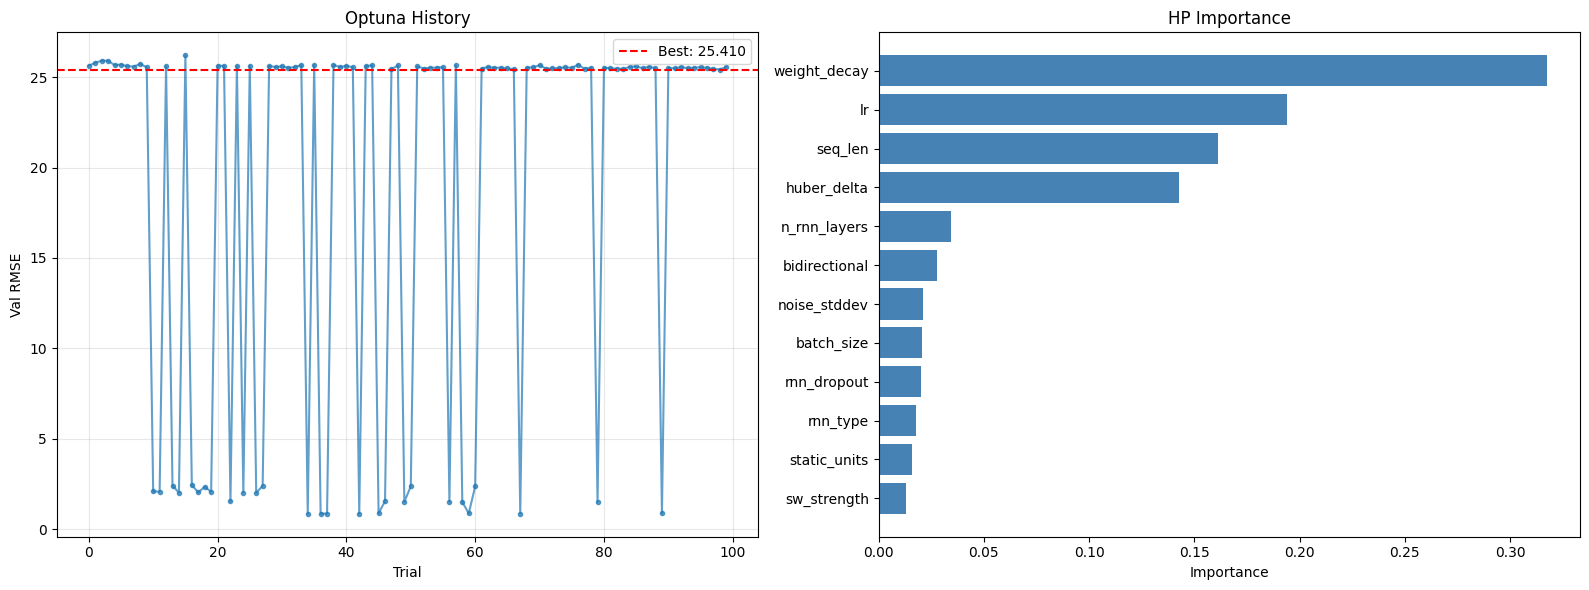

In [ ]:
from optuna.importance import get_param_importances

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# History
ax = axes[0]
vals = [t.value for t in rnn_study.trials if t.value is not None]
ax.plot(vals, 'o-', markersize=3, alpha=0.7)
ax.axhline(y=rnn_study.best_value, color='r', linestyle='--',
           label=f'Best: {rnn_study.best_value:.3f}')
ax.set_xlabel('Trial'); ax.set_ylabel('Val RMSE')
ax.set_title('Optuna History'); ax.legend(); ax.grid(True, alpha=0.3)

# Importance
ax = axes[1]
try:
    imp = get_param_importances(rnn_study)
    top = dict(list(imp.items())[:12])
    ax.barh(list(top.keys())[::-1], list(top.values())[::-1], color='steelblue')
    ax.set_title('HP Importance'); ax.set_xlabel('Importance')
except Exception as e:
    ax.text(0.5, 0.5, str(e), transform=ax.transAxes, ha='center')

plt.tight_layout()
plt.savefig('../../results/rnn_improved_optuna_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Learning Curves

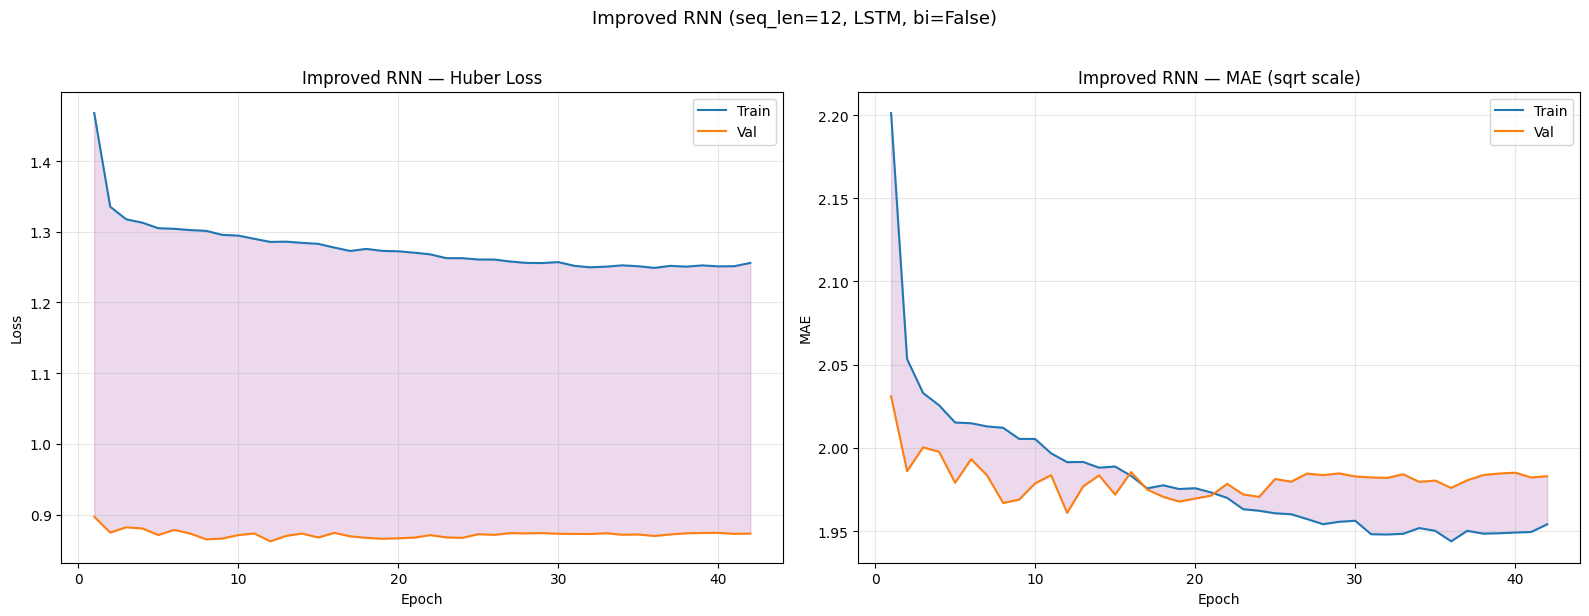

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
epochs = range(1, len(history_rnn.history['loss']) + 1)

# Loss
ax = axes[0]
ax.plot(epochs, history_rnn.history['loss'], label='Train', linewidth=1.5)
ax.plot(epochs, history_rnn.history['val_loss'], label='Val', linewidth=1.5)
ax.fill_between(epochs, history_rnn.history['loss'], history_rnn.history['val_loss'],
                alpha=0.15, color='purple')
ax.set_title('Improved RNN — Huber Loss', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(True, alpha=0.3)

# MAE
ax = axes[1]
ax.plot(epochs, history_rnn.history['mae'], label='Train', linewidth=1.5)
ax.plot(epochs, history_rnn.history['val_mae'], label='Val', linewidth=1.5)
ax.fill_between(epochs, history_rnn.history['mae'], history_rnn.history['val_mae'],
                alpha=0.15, color='purple')
ax.set_title('Improved RNN — MAE (sqrt scale)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('MAE')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Improved RNN (seq_len={best_seq_len}, {bp["rnn_type"]}, bi={bp["bidirectional"]})',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../../results/rnn_improved_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Full Comparison - All Models

In [33]:
# Reference results from all previous notebooks
reference_results = {
    'XGBoost (184 feat)':            {'Test MAE': 18.15, 'Test RMSE': 25.15, 'Test R2': 0.3335, 'Type': 'Tree'},
    'LightGBM (184 feat)':           {'Test MAE': 18.15, 'Test RMSE': 25.13, 'Test R2': 0.3346, 'Type': 'Tree'},
    'MLP-B (40 feat)':               {'Test MAE': 18.19, 'Test RMSE': 25.23, 'Test R2': 0.3289, 'Type': 'MLP'},
    'MLP-E Hybrid (40 feat)':        {'Test MAE': 17.88, 'Test RMSE': 25.35, 'Test R2': 0.3225, 'Type': 'MLP'},
    'MLP-D Fixed Hybrid (40 feat)':  {'Test MAE': 17.83, 'Test RMSE': 25.67, 'Test R2': 0.3055, 'Type': 'MLP'},
    'Original RNN (184 feat)':       {'Test MAE': 19.73, 'Test RMSE': 27.93, 'Test R2': 0.2157, 'Type': 'RNN (old)'},
    'Original TCN (184 feat)':       {'Test MAE': 19.30, 'Test RMSE': 27.59, 'Test R2': 0.2453, 'Type': 'TCN (old)'},
}

# New RNN
rnn_metrics = get_final_metrics(history_rnn)
reference_results['Improved RNN (raw feat)'] = {
    'Test MAE': mae_rnn, 'Test RMSE': rmse_rnn, 'Test R2': r2_rnn,
    'Type': 'RNN (new)',
    'Loss Gap': rnn_metrics['Loss Gap'],
    'Best Epoch': rnn_metrics['Best Epoch'],
}

comp_df = pd.DataFrame(reference_results).T
comp_df.index.name = 'Model'
comp_df = comp_df.sort_values('Test R2', ascending=False)

print('\n' + '=' * 85)
print('FULL MODEL COMPARISON — All Architectures')
print('=' * 85)
print(comp_df[['Type', 'Test MAE', 'Test RMSE', 'Test R2']].round(4).to_string())
print('=' * 85)

# RNN improvement
print(f'\n--- RNN Improvement ---')
print(f'Original RNN: MAE=19.73  RMSE=27.93  R2=0.2157')
print(f'Improved RNN: MAE={mae_rnn:.2f}  RMSE={rmse_rnn:.2f}  R2={r2_rnn:.4f}')
print(f'  MAE change:  {mae_rnn - 19.73:+.2f}')
print(f'  RMSE change: {rmse_rnn - 27.93:+.2f}')
print(f'  R2 change:   {r2_rnn - 0.2157:+.4f}')


FULL MODEL COMPARISON — All Architectures
                                   Type   Test MAE Test RMSE   Test R2
Model                                                                 
Improved RNN (raw feat)       RNN (new)  18.028921  25.11007  0.335433
LightGBM (184 feat)                Tree      18.15     25.13    0.3346
XGBoost (184 feat)                 Tree      18.15     25.15    0.3335
MLP-B (40 feat)                     MLP      18.19     25.23    0.3289
MLP-E Hybrid (40 feat)              MLP      17.88     25.35    0.3225
MLP-D Fixed Hybrid (40 feat)        MLP      17.83     25.67    0.3055
Original TCN (184 feat)       TCN (old)       19.3     27.59    0.2453
Original RNN (184 feat)       RNN (old)      19.73     27.93    0.2157

--- RNN Improvement ---
Original RNN: MAE=19.73  RMSE=27.93  R2=0.2157
Improved RNN: MAE=18.03  RMSE=25.11  R2=0.3354
  MAE change:  -1.70
  RMSE change: -2.82
  R2 change:   +0.1197


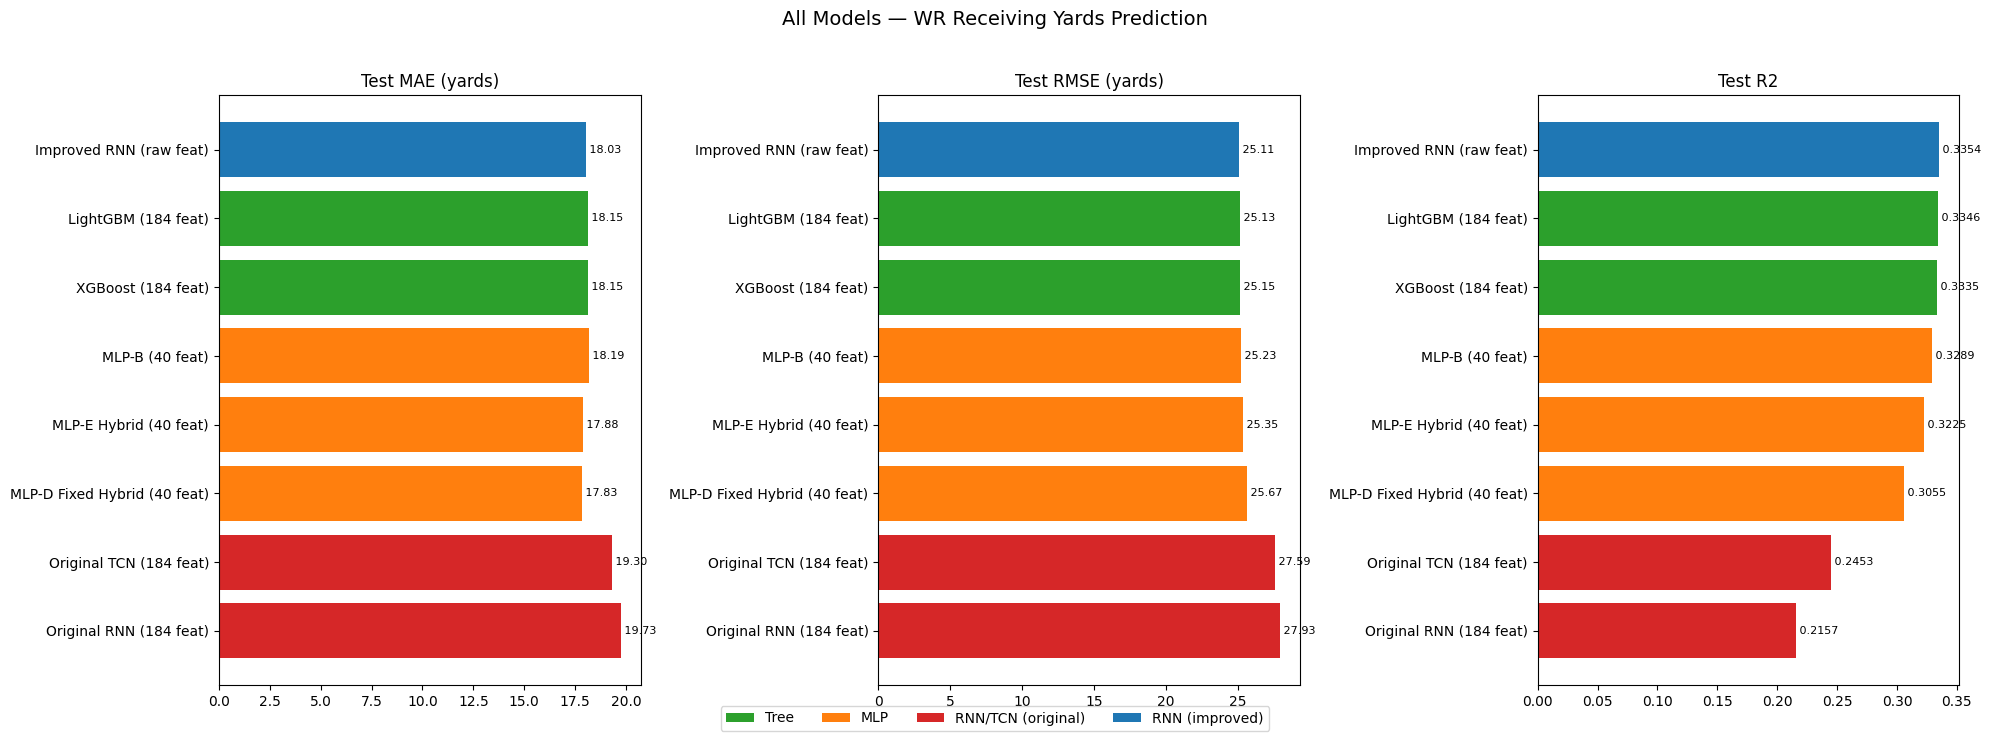

In [ ]:
# --- Bar chart: all models ---
plot_df = comp_df[['Test MAE', 'Test RMSE', 'Test R2']].copy()

# Color by type
type_colors = {
    'Tree': '#2ca02c',
    'MLP': '#ff7f0e',
    'RNN (old)': '#d62728',
    'TCN (old)': '#d62728',
    'RNN (new)': '#1f77b4',
}
colors = [type_colors.get(comp_df.loc[m, 'Type'], 'gray') for m in plot_df.index]

fig, axes = plt.subplots(1, 3, figsize=(20, 7))

for idx, (metric, title) in enumerate([
    ('Test MAE', 'Test MAE (yards)'),
    ('Test RMSE', 'Test RMSE (yards)'),
    ('Test R2', 'Test R2'),
]):
    ax = axes[idx]
    vals = plot_df[metric].values
    ax.barh(plot_df.index, vals, color=colors)
    ax.set_title(title, fontsize=12)
    ax.invert_yaxis()
    for i, v in enumerate(vals):
        fmt = '.2f' if 'MAE' in metric or 'RMSE' in metric else '.4f'
        ax.text(v, i, f' {v:{fmt}}', va='center', fontsize=8)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', label='Tree'),
    Patch(facecolor='#ff7f0e', label='MLP'),
    Patch(facecolor='#d62728', label='RNN/TCN (original)'),
    Patch(facecolor='#1f77b4', label='RNN (improved)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('All Models — WR Receiving Yards Prediction', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../../results/rnn_improved_full_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Save results
output = {
    'best_params': rnn_study.best_params,
    'best_val_rmse': rnn_study.best_value,
    'test_mae': round(mae_rnn, 4),
    'test_rmse': round(rmse_rnn, 4),
    'test_r2': round(r2_rnn, 4),
    'seq_features': seq_feature_cols,
    'static_features': static_feature_cols,
    'n_seq_features': n_seq_features,
    'n_static_features': n_static_features,
    'training_metrics': {k: round(v, 4) if isinstance(v, float) else v
                         for k, v in rnn_metrics.items()},
    'comparison': {k: {kk: round(vv, 4) if isinstance(vv, float) else vv
                       for kk, vv in v.items()}
                   for k, v in reference_results.items()},
}

with open('../../results/rnn_improved_results.json', 'w') as f:
    json.dump(output, f, indent=2, default=str)

comp_df.to_csv('../../results/all_models_comparison.csv')

print('Saved:')
print('  results/rnn_improved_results.json')
print('  results/all_models_comparison.csv')
print(f'\n=== DONE ===')
print(f'Improved RNN: MAE={mae_rnn:.2f}  RMSE={rmse_rnn:.2f}  R2={r2_rnn:.4f}')

Saved:
  results/rnn_improved_results.json
  results/all_models_comparison.csv

=== DONE ===
Improved RNN: MAE=18.03  RMSE=25.11  R2=0.3354
